<a href="https://colab.research.google.com/github/adhalifz-zen/Analisis-sentimen-menggunakan-SVM/blob/main/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

## **Pratinjau dan masukan data**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/SKRIPSI/preprocesing data/kendaraanlistrik.csv")
df[['text', 'label']] = df['text;label'].str.split(';', expand=True)
df.drop(columns=['text;label'], inplace=True)
df['label'] = df['label'].map({'positif': 1, 'negatif': 0})
df.head()

,text,label
0,mercedes amp bmw desak jerman tolak tarif kend...,1
1,presiden jokowi ikn energi hijau sepenuh kenda...,1
2,dah ya knp perintah ngotot kendara listrik,1
3,ooooooo luhut kemaren nyuruh pake kendara list...,1
4,moeldoko kawal proyek baterai kendara listrik ksp,1


## **Preprocessing & TF-IDF**

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['text'])
y = df['label']

## **Split Data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (991, 3610)
X_test shape: (248, 3610)
y_train shape: (991,)
y_test shape: (248,)


## **Training Model SVM**

In [ ]:
model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

## **Evaluasi Model**

In [ ]:
y_pred = model.predict(X_test)
print("✅ Akurasi Model: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\n📄 Laporan Klasifikasi:\n")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Positif']))

✅ Akurasi Model: 78.23%

📄 Laporan Klasifikasi:

              precision    recall  f1-score   support

     Negatif       0.76      0.62      0.68        94
     Positif       0.79      0.88      0.83       154

    accuracy                           0.78       248
   macro avg       0.78      0.75      0.76       248
weighted avg       0.78      0.78      0.78       248



## **Visualisasi Confusion Matrix**

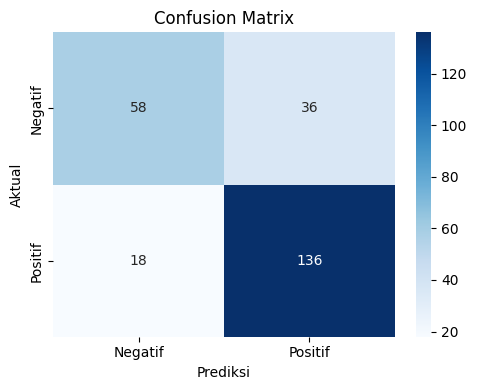

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()